Q1. Polynomial Regression –
House Price Prediction
Objective :-
To implement Polynomial Regression for predicting house prices when the
relationship between the input feature and target variable is non-linear.
Problem Statement :-
A real-estate company wants to predict the price of a house based on its area.
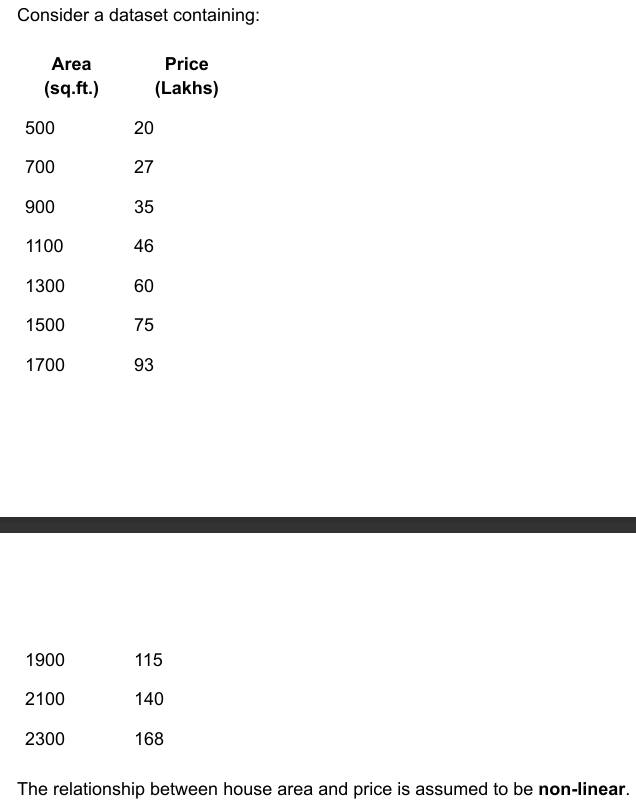
Tasks
1. Create a dataset containing at least 30 house records.
2. Load the dataset using Pandas.
3. Perform basic exploratory data analysis.
4. Visualize the relationship between:
○ House Area
○ House Price
5. Divide the data into training and testing sets.
6. Apply Polynomial Features with degree 2.
7. Train a Polynomial Regression model.
8. Repeat the experiment using polynomial degrees:
○ Degree 2
○ Degree 3
○ Degree 4
9. Compare the models using:
○ Mean Absolute Error (MAE)
○ Mean Squared Error (MSE)
○ Root Mean Squared Error (RMSE)
○ R² Score
10. Plot the original data points and the regression curves.
11. Determine which polynomial degree gives the best performance.
12. Predict the price of a house having an area of 2000 sq.ft.
Expected Output :-
The program should display:
● Dataset
● Scatter plot of Area vs Price
● Regression curve for different polynomial degrees
● MAE for each model
● MSE for each model
● RMSE for each model
● R² Score for each model
● Best polynomial degree
● Predicted price for a 2000 sq.ft. house

House Price Dataset:
    Area  Price
0    500   20.0
1    600   23.2
2    700   27.0
3    800   31.0
4    900   35.0
5   1000   40.0
6   1100   46.0
7   1200   52.5
8   1300   60.0
9   1400   67.0
10  1500   75.0
11  1600   84.0
12  1700   93.0
13  1800  103.0
14  1900  115.0
15  2000  127.0
16  2100  140.0
17  2200  154.0
18  2300  168.0
19  2400  184.0
20  2500  200.0
21  2600  217.0
22  2700  235.0
23  2800  254.0
24  2900  274.0
25  3000  295.0
26  3100  317.0
27  3200  340.0
28  3300  364.0
29  3400  389.0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Area    30 non-null     int64  
 1   Price   30 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None

Statistical Summary:
              Area      Price
count    30.000000   30.00000
mean   1950.000000  150.99000
std     880.340843  112.95423
min     5

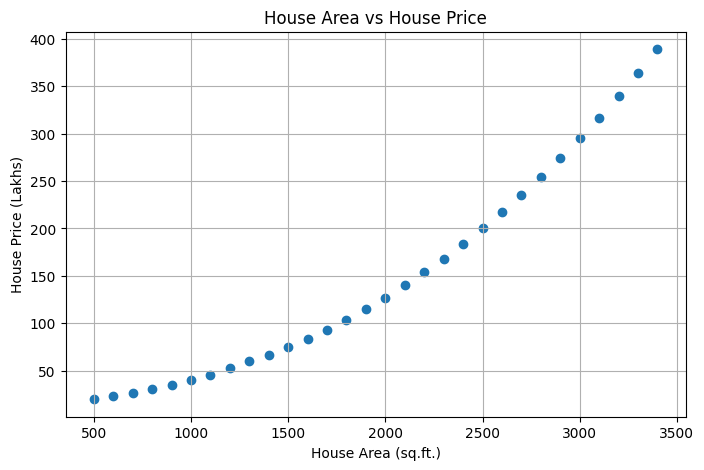


Training Dataset Size: 24
Testing Dataset Size: 6

Model Comparison:
 Polynomial Degree      MAE      MSE     RMSE  R2 Score
                 2 1.576759 3.577106 1.891324  0.999647
                 3 0.345403 0.238462 0.488325  0.999976
                 4 0.351713 0.229042 0.478584  0.999977



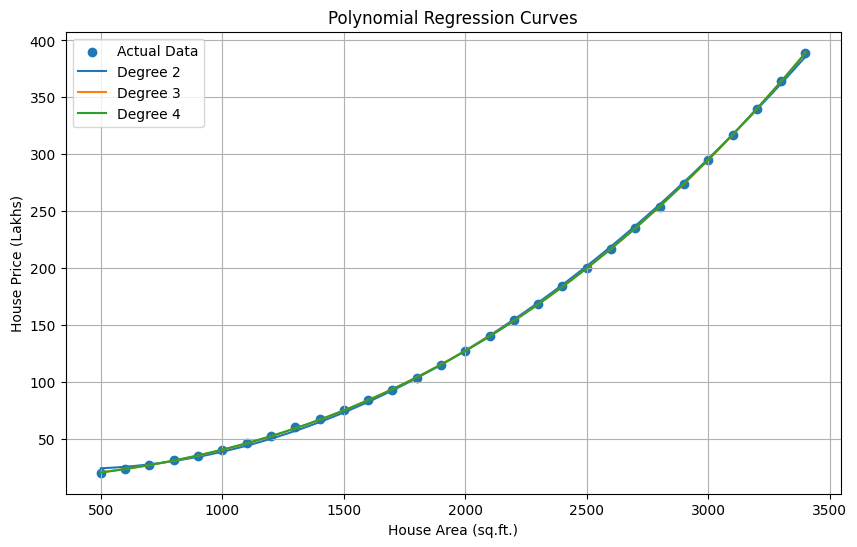


Best Polynomial Degree: 4
Predicted price for a 2000 sq.ft. house: 127.00 Lakhs


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Create dataset with at least 30 house records

data = {
    "Area": [
        500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400,
        1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400,
        2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400
    ],

    "Price": [
        20, 23.2, 27, 31, 35, 40, 46, 52.5, 60, 67,
        75, 84, 93, 103, 115, 127, 140, 154, 168, 184,
        200, 217, 235, 254, 274, 295, 317, 340, 364, 389
    ]
}

df = pd.DataFrame(data)

# 2. Display the dataset

print("House Price Dataset:")
print(df)

# 3. Basic Exploratory Data Analysis

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())
print()

# 4. Visualize Area vs Price

plt.figure(figsize=(8, 5))

plt.scatter(df["Area"], df["Price"])

plt.xlabel("House Area (sq.ft.)")
plt.ylabel("House Price (Lakhs)")
plt.title("House Area vs House Price")

plt.grid(True)
plt.show()

# 5. Divide data into training and testing sets

X = df[["Area"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Dataset Size:", len(X_train))
print("Testing Dataset Size:", len(X_test))

# 6-8. Polynomial Regression for degrees 2, 3 and 4

degrees = [2, 3, 4]

results = []

models = {}

for degree in degrees:

    # Create Polynomial Regression model
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )

    # Train the model
    model.fit(X_train, y_train)

    # Predict test data
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store model
    models[degree] = model

    # Store results
    results.append([
        degree,
        mae,
        mse,
        rmse,
        r2
    ])

# 9. Display model comparison

results_df = pd.DataFrame(
    results,
    columns=["Polynomial Degree", "MAE", "MSE", "RMSE", "R2 Score"]
)

print("\nModel Comparison:")
print(results_df.to_string(index=False))
print()

# 10. Plot regression curves

X_curve = np.linspace(
    df["Area"].min(),
    df["Area"].max(),
    300
).reshape(-1, 1)

plt.figure(figsize=(10, 6))

# Original data points
plt.scatter(
    df["Area"],
    df["Price"],
    label="Actual Data"
)

# Regression curves
for degree in degrees:

    model = models[degree]

    y_curve = model.predict(
        pd.DataFrame(X_curve, columns=["Area"])
    )

    plt.plot(
        X_curve,
        y_curve,
        label=f"Degree {degree}"
    )

plt.xlabel("House Area (sq.ft.)")
plt.ylabel("House Price (Lakhs)")
plt.title("Polynomial Regression Curves")

plt.legend()
plt.grid(True)
plt.show()

# 11. Determine the best polynomial degree

best_degree = results_df.loc[
    results_df["R2 Score"].idxmax(),
    "Polynomial Degree"
]

print("\nBest Polynomial Degree:", best_degree)

# 12. Predict price for a 2000 sq.ft. house

best_model = models[best_degree]

new_house = pd.DataFrame(
    {"Area": [2000]}
)

predicted_price = best_model.predict(new_house)[0]

print(
    f"Predicted price for a 2000 sq.ft. house: "
    f"{predicted_price:.2f} Lakhs"
)

Q2.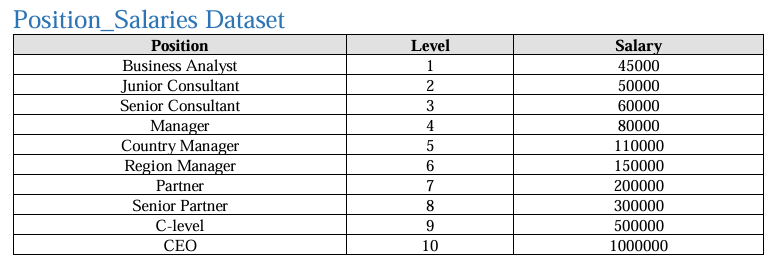
Questions
1. Using the given dataset (Position, Level, Salary): - Split the dataset into features (X = Level) and labels (y = Salary). - Train a Linear Regression model on the whole dataset.
1000000
2. Train a Polynomial Regression model of degree 4 on the same dataset using PolynomialFeatures and
LinearRegression.
3. Visualize the Linear Regression results by plotting the actual data points against the predicted regression line.
4. Visualize the Polynomial Regression results by plotting the actual data points against the predicted polynomial
curve.
5. Improve the polynomial regression plot's resolution and smoothness using a finer grid (np.arange with a smaller
step size).
6. Predict the salary for a Position Level of 6.5 using: - The Linear Regression model - The Polynomial Regression model
7. Compare the predictions from both models and conclude which one gives a more realistic/accurate result for the
"Truth or Bluff" salary problem.

Position Salaries Dataset:
            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000

Linear Regression:
Coefficient: 80878.78787878789
Intercept: -195333.33333333337

Polynomial Regression:
Coefficients:
[0.00000000 -211002.33100292 94765.44289063 -15463.28671331 890.15151515 ]
Intercept: 184166.66666720



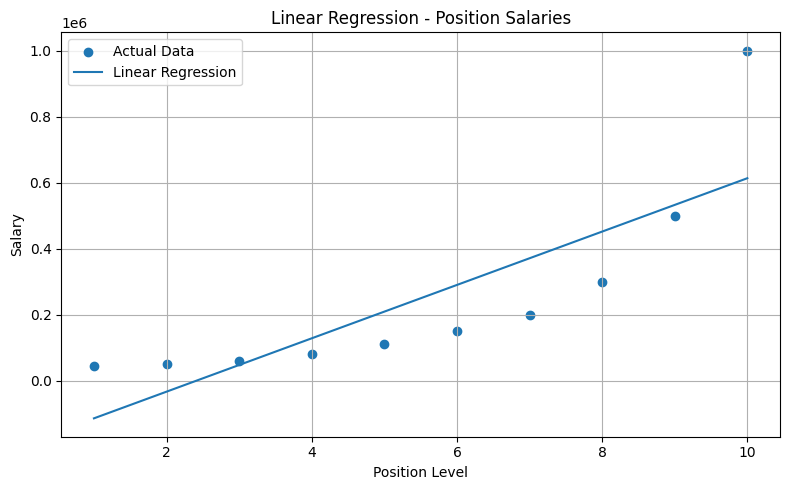

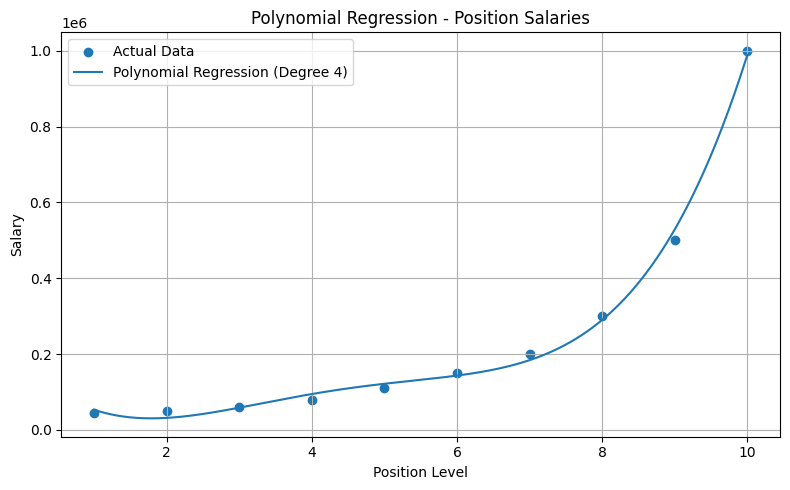


Prediction for Position Level 6.5:
Linear Regression: ₹330378.79
Polynomial Regression: ₹158862.45

Comparison:
Linear Regression predicts: ₹330378.79
Polynomial Regression predicts: ₹158862.45

Conclusion:
Polynomial Regression gives a more realistic prediction for this dataset because the relationship between Position Level and Salary is non-linear.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Create the dataset

data = {
    "Position": [
        "Business Analyst",
        "Junior Consultant",
        "Senior Consultant",
        "Manager",
        "Country Manager",
        "Region Manager",
        "Partner",
        "Senior Partner",
        "C-level",
        "CEO"
    ],

    "Level": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],

    "Salary": [
        45000,
        50000,
        60000,
        80000,
        110000,
        150000,
        200000,
        300000,
        500000,
        1000000
    ]
}

df = pd.DataFrame(data)

# 2. Display the dataset

print("Position Salaries Dataset:")
print(df)

# 3. Separate features and labels

X = df[["Level"]]
y = df["Salary"]

# 4. Linear Regression

linear_model = LinearRegression()

linear_model.fit(X, y)

y_linear_pred = linear_model.predict(X)


print("\nLinear Regression:")
print("Coefficient:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

# 5. Polynomial Regression - Degree 4

poly = PolynomialFeatures(degree=4)

X_poly = poly.fit_transform(X)

poly_model = LinearRegression()

poly_model.fit(X_poly, y)

y_poly_pred = poly_model.predict(X_poly)

# 6. Display Polynomial Coefficients as Array

print("\nPolynomial Regression:")
print("Coefficients:")
print("[", end="")

for i, coefficient in enumerate(poly_model.coef_):
    print(f"{coefficient:.8f}", end=" ")

print("]")
print(f"Intercept: {poly_model.intercept_:.8f}")
print()

# 7. Linear Regression Plot

plt.figure(figsize=(8, 5))

plt.scatter(
    X["Level"],
    y,
    label="Actual Data"
)

plt.plot(
    X["Level"],
    y_linear_pred,
    label="Linear Regression"
)

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Linear Regression - Position Salaries")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()
print()

# 8. Polynomial Regression Plot

# Create a fine grid for smooth curve
X_grid = pd.DataFrame({
    "Level": np.arange(1, 10.01, 0.01)
})

# Convert grid into polynomial features
X_grid_poly = poly.transform(X_grid)

# Predict using polynomial regression
y_grid_pred = poly_model.predict(X_grid_poly)


plt.figure(figsize=(8, 5))

plt.scatter(
    X["Level"],
    y,
    label="Actual Data"
)

plt.plot(
    X_grid["Level"],
    y_grid_pred,
    label="Polynomial Regression (Degree 4)"
)

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression - Position Salaries")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# 9. Predict salary for Position Level 6.5

# Use DataFrame to avoid feature-name warnings
level_6_5 = pd.DataFrame({
    "Level": [6.5]
})

# Linear Regression prediction
linear_prediction = linear_model.predict(level_6_5)[0]

# Polynomial Regression prediction
level_6_5_poly = poly.transform(level_6_5)

polynomial_prediction = poly_model.predict(
    level_6_5_poly
)[0]

# 10. Display Predictions

print("\nPrediction for Position Level 6.5:")

print(
    f"Linear Regression: ₹{linear_prediction:.2f}"
)

print(
    f"Polynomial Regression: ₹{polynomial_prediction:.2f}"
)

# 11. Comparison

print("\nComparison:")

print(
    f"Linear Regression predicts: "
    f"₹{linear_prediction:.2f}"
)

print(
    f"Polynomial Regression predicts: "
    f"₹{polynomial_prediction:.2f}"
)

# 12. Conclusion

print("\nConclusion:")

print(
    "Polynomial Regression gives a more realistic "
    "prediction for this dataset because the relationship "
    "between Position Level and Salary is non-linear."
)